# 1. Giải nén dataset và hiển thị thông tin dữ liệu
Đoạn code dưới đây sẽ tự động giải nén file `dataset.zip` (nếu chưa được giải nén) và thống kê số lượng ảnh thật/giả trong dữ liệu.

In [1]:
import os
import zipfile
from pathlib import Path

# Cấu hình đường dẫn
DATASET_ZIP = "../datasets/dataset.zip"
EXTRACT_DIR = "../datasets/extracted_data"

# 1. Giải nén dataset
if not os.path.exists(EXTRACT_DIR):
    print(f"Đang giải nén {DATASET_ZIP} vào {EXTRACT_DIR}...")
    with zipfile.ZipFile(DATASET_ZIP, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)
    print("Giải nén hoàn tất!")
else:
    print(f"Dữ liệu đã được giải nén tại {EXTRACT_DIR}.")

# 2. Hiển thị thông tin dữ liệu (số lượng ảnh theo thư mục)
print("\n--- Thông tin Data ---")
extracted_path = Path(EXTRACT_DIR)
image_extensions = {".jpg", ".jpeg", ".png", ".webp"}
total_images = 0

# Duyệt qua các thư mục con trong 'images'
for real_fake_dir in sorted(extracted_path.glob("images/*")):
    if real_fake_dir.is_dir():
        print(f"\nPhân loại: {real_fake_dir.name}")
        for category_dir in sorted(real_fake_dir.iterdir()):
            if category_dir.is_dir():
                images_count = sum(
                    1 for file in category_dir.iterdir() 
                    if file.suffix.lower() in image_extensions
                )
                print(f"  - {category_dir.name}: {images_count} ảnh")
                total_images += images_count

print(f"\nTổng số ảnh trong dataset: {total_images} ảnh")

Đang giải nén ../datasets/dataset.zip vào ../datasets/extracted_data...
Giải nén hoàn tất!

--- Thông tin Data ---

Phân loại: fake
  - FLUX_DEV: 7273 ảnh
  - FLUX_PRO: 3209 ảnh
  - SDXL: 53087 ảnh

Phân loại: real

Tổng số ảnh trong dataset: 63569 ảnh


# 2. Khởi tạo Pipeline SSD-1B-Traditional
Sử dụng thư viện `diffusers` để load mô hình con của SDXL. Mặc định dùng `StableDiffusionXLPipeline` vì cấu trúc hai model này hoàn toàn tương thích.

In [2]:
import torch
from diffusers import StableDiffusionXLPipeline

# Cấu hình thiết bị (Hỗ trợ tốt nhất trên GPU hoặc Apple Silicon MPS)
device = "mps" if torch.backends.mps.is_available() else ("cuda" if torch.cuda.is_available() else "cpu")
dtype = torch.float16 if device in ["mps", "cuda"] else torch.float32

# Đường dẫn folder chứa model trong thư mục làm việc
model_path = "../SSD-1B-Traditional"

print(f"Đang load mô hình từ {model_path} bằng bộ giả lập {device}...")

# Load pipeline SSD-1B-Traditional (tương thích hoàn toàn với SDXL)
pipe = StableDiffusionXLPipeline.from_pretrained(
    model_path,
    torch_dtype=dtype,
    use_safetensors=True
).to(device)

print("Load mô hình SSD-1B-Traditional thành công!")

/Users/khang/Downloads/lab02/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Đang load mô hình từ ../SSD-1B-Traditional bằng bộ giả lập mps...


Loading weights: 100%|██████████| 517/517 [00:01<00:00, 327.36it/s] 4.18it/s]
CLIPTextModelWithProjection LOAD REPORT from: ../SSD-1B-Traditional/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading weights: 100%|██████████| 196/196 [00:00<00:00, 462.66it/s] 2.48s/it]
CLIPTextModel LOAD REPORT from: ../SSD-1B-Traditional/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Loading pipeline components...: 100%|██████████| 7/7 [00:06<00:00,  1.06it/s]


Load mô hình SSD-1B-Traditional thành công!


# 3. Hàm Tiền xử lý & DIRE
Quá trình tạo lại ảnh theo thuật toán DIRE (DDIM Inversion + Reconstruction) được định nghĩa qua hàm `run_dire_process`. 
Lưu ý: SDXL cần thêm tham số `added_cond_kwargs`. Dữ liệu sẽ lấy từ ảnh Fake nhóm SDXL và một số ảnh Real.

In [25]:
from PIL import Image

def run_dire_process(image_path, steps=20):
    # 1. Tiền xử lý ảnh
    raw_image = Image.open(image_path).convert("RGB").resize((1024, 1024))
    image_tensor = pipe.image_processor.preprocess(raw_image).to(pipe.device).to(pipe.dtype)

    # 2. Trích xuất embeddings cho SDXL
    (prompt_embeds, 
     negative_prompt_embeds, 
     pooled_prompt_embeds, 
     negative_pooled_prompt_embeds) = pipe.encode_prompt(
         prompt="", 
         device=pipe.device, 
         num_images_per_prompt=1, 
         do_classifier_free_guidance=False
     )
    
    projection_dim = int(pooled_prompt_embeds.shape[-1])
    
    add_time_ids = pipe._get_add_time_ids(
        (1024, 1024), 
        (0, 0), 
        (1024, 1024), 
        dtype=prompt_embeds.dtype,
        text_encoder_projection_dim=projection_dim
    ).to(pipe.device)
    
    added_cond_kwargs = {"text_embeds": pooled_prompt_embeds, "time_ids": add_time_ids}

    from diffusers import DDIMScheduler
    pipe.scheduler = DDIMScheduler.from_config(pipe.scheduler.config)

    # 3. Encode sang Latent
    pipe.upcast_vae() 
    image_tensor_fp32 = image_tensor.to(torch.float32)

    with torch.no_grad():
        latents = pipe.vae.encode(image_tensor_fp32).latent_dist.sample() * pipe.vae.config.scaling_factor
    latents = latents.to(pipe.dtype)
    print(f"[Debug] Latents sau khi encode - min: {latents.min().item():.3f}, max: {latents.max().item():.3f}")

    # 4. DDIM Inversion 
    # (Đã sửa lại CÔNG THỨC TOÁN HỌC đảo ngược của DDIM - công thức cũ bị sai)
    pipe.scheduler.set_timesteps(steps)
    inv_latents = latents.clone()
    timesteps = pipe.scheduler.timesteps.flip(0)
    
    with torch.no_grad():
        for i, t in enumerate(timesteps):
            noise_pred = pipe.unet(
                inv_latents, 
                t, 
                encoder_hidden_states=prompt_embeds, 
                added_cond_kwargs=added_cond_kwargs
            ).sample
            
            # Lấy alpha tương ứng
            alpha_prod_t = pipe.scheduler.alphas_cumprod[t.cpu()].to(pipe.device)
            if i < len(timesteps) - 1:
                t_next = timesteps[i+1]
                alpha_prod_t_next = pipe.scheduler.alphas_cumprod[t_next.cpu()].to(pipe.device)
            else:
                alpha_prod_t_next = pipe.scheduler.alphas_cumprod[-1].to(pipe.device)
                
            # DDIM INVERSE FORMULA CHUẨN
            pred_x0 = (inv_latents - (1 - alpha_prod_t)**0.5 * noise_pred) / (alpha_prod_t**0.5)
            inv_latents = alpha_prod_t_next**0.5 * pred_x0 + (1 - alpha_prod_t_next)**0.5 * noise_pred
            
            torch.nan_to_num(inv_latents, nan=0.0, out=inv_latents)

        print(f"[Debug] Latents sau Inversion - min: {inv_latents.min().item():.3f}, max: {inv_latents.max().item():.3f}")

        # 5. Reconstruction
        recon_latents = inv_latents
        for t in pipe.scheduler.timesteps:
            noise_pred = pipe.unet(
                recon_latents, 
                t, 
                encoder_hidden_states=prompt_embeds, 
                added_cond_kwargs=added_cond_kwargs
            ).sample
            
            recon_latents = pipe.scheduler.step(noise_pred, t, recon_latents).prev_sample
            torch.nan_to_num(recon_latents, nan=0.0, out=recon_latents)

        print(f"[Debug] Latents sau Reconstruction - min: {recon_latents.min().item():.3f}, max: {recon_latents.max().item():.3f}")

        # 6. Decode
        recon_latents_fp32 = recon_latents.to(torch.float32)
        recon_image = pipe.vae.decode(recon_latents_fp32 / pipe.vae.config.scaling_factor, return_dict=False)[0]
        # In giá trị màu cơ bản
        print(f"[Debug] Ảnh giải mã thô - min: {recon_image.min().item():.3f}, max: {recon_image.max().item():.3f}")
        
        recon_image = pipe.image_processor.postprocess(recon_image)[0]

    return raw_image, recon_image

print("Đã cập nhật run_dire_process: Fix CÔNG THỨC TOÁN HỌC DDIM Inversion và thêm các điểm in Debug!")

# Test một hình ảnh fake từ SDXL
sdxl_fake_dir = Path(EXTRACT_DIR) / "images" / "fake" / "SDXL"
real_dir = Path(EXTRACT_DIR) / "images" / "real"

if sdxl_fake_dir.exists():
    sample_fake = list(sdxl_fake_dir.glob("*.jpg"))[1]
    print(f"\nChúng ta có thể xử lý thử ảnh fake từ: {sample_fake.name}")
else:
    print("\nKhông tìm thấy mục ảnh fake từ SDXL.")

Đã cập nhật run_dire_process: Fix CÔNG THỨC TOÁN HỌC DDIM Inversion và thêm các điểm in Debug!

Chúng ta có thể xử lý thử ảnh fake từ: SDXL_image_0039321.jpg


# 4. Thử nghiệm quá trình DIRE và biểu diễn DIRE Map
Thử nghiệm trên 1 ảnh thật hoặc giả (ở đây sử dụng ảnh từ SDXL) và visualize bản đồ sai số (DIRE MAP) giữa ảnh gốc và ảnh khôi phục.

Đang xử lý ảnh: ../datasets/extracted_data/images/fake/SDXL/SDXL_image_0039321.jpg
[Debug] Latents sau khi encode - min: -2.469, max: 3.232
[Debug] Latents sau Inversion - min: -3.201, max: 3.756
[Debug] Latents sau Reconstruction - min: -1.826, max: 2.248
[Debug] Ảnh giải mã thô - min: -1.060, max: 0.932


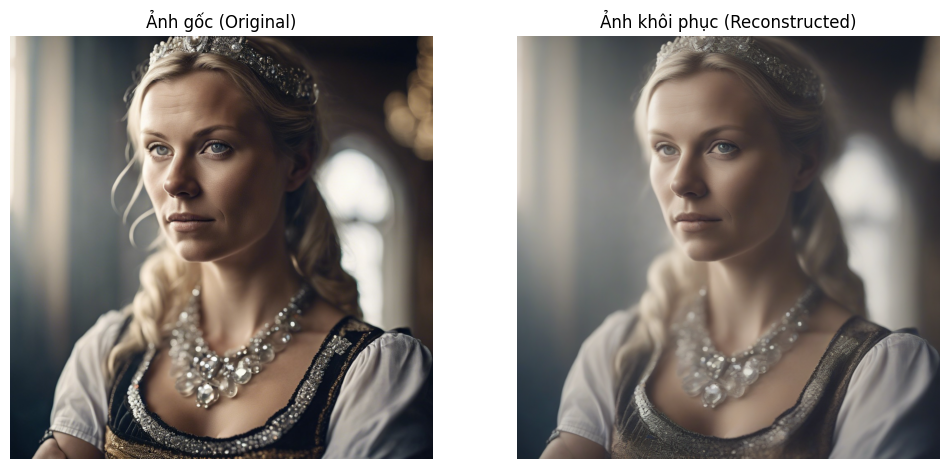

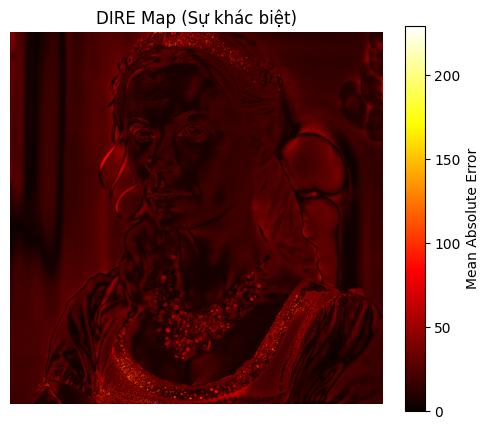

In [26]:
import matplotlib.pyplot as plt
import numpy as np
import traceback

try:
    # Ở cell trước, biến "sample_fake" đã được tìm và lưu.
    # Chúng ta dùng luôn đường dẫn này để thử nghiệm.
    sample_path = sample_fake
    print(f"Đang xử lý ảnh: {sample_path}")

    # Chạy quy trình DIRE (Inversion + Reconstruction)
    original, reconstructed = run_dire_process(sample_path)

    # Tính toán bản đồ sai số (DIRE Map)
    orig_np = np.array(original).astype(np.float32)
    recon_np = np.array(reconstructed).astype(np.float32)
    error_map = np.abs(orig_np - recon_np).mean(axis=-1)

    # Hiển thị kết quả Ảnh Gốc (Original) & Ảnh Khôi phục (Reconstructed)
    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.title("Ảnh gốc (Original)")
    plt.imshow(original)
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title("Ảnh khôi phục (Reconstructed)")
    plt.imshow(reconstructed)
    plt.axis('off')

    plt.show()

    # Hiển thị riêng bản đồ sai số (DIRE Map)
    plt.figure(figsize=(6, 5))
    plt.title("DIRE Map (Sự khác biệt)")
    # Dùng colormap "hot" hoặc "jet" cho Dire Map để thấy rõ các khu vực sai số lớn
    plt.imshow(error_map, cmap='hot')
    plt.colorbar(label='Mean Absolute Error')
    plt.axis('off')
    plt.show()

except NameError:
    print("Không tìm thấy biến 'sample_fake'. Vui lòng chạy cell phía trên để xác định đường dẫn file.")
except Exception as e:
    print(f"Có lỗi xảy ra: {e}")
    traceback.print_exc()